In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [3]:
# 2: Load dataset
df = pd.read_csv("day.csv")   # change to hour.csv if needed
df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# 2: Load dataset
df = pd.read_csv("hour.csv")   # change to hour.csv if needed
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
# 4: Drop unnecessary columns
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

In [7]:
# 5: Convert target (cnt → High/Low demand)
threshold = df['cnt'].median()
df['demand'] = df['cnt'].apply(lambda x: 1 if x > threshold else 0)


In [8]:
# Drop original cnt
df = df.drop('cnt', axis=1)

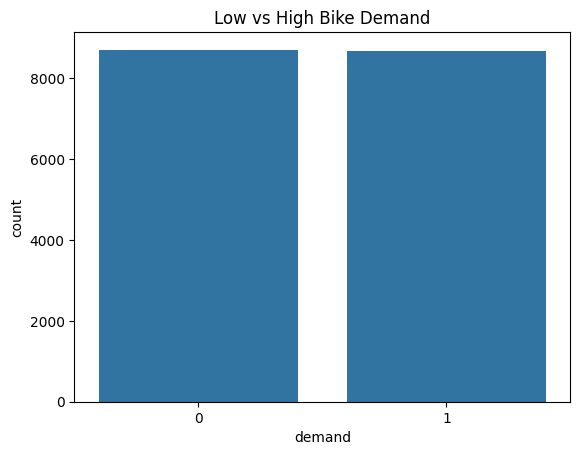

In [9]:
# 6: Visualization
sns.countplot(x='demand', data=df)
plt.title("Low vs High Bike Demand")
plt.show()


In [10]:
# 7: Encoding (if needed)
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [11]:
# 8: Features & Target
X = df.drop("demand", axis=1)
y = df["demand"]


In [12]:
# 9: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
# Result storage
results_8020 = []
results_7030 = []

In [14]:
# =========================
# 10: Logistic Regression
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
acc_lr_80 = accuracy_score(y_test, lr.predict(X_test))
results_8020.append(['Logistic Regression', acc_lr_80])

In [15]:
# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
lr.fit(X_train, y_train)
acc_lr_70 = accuracy_score(y_test, lr.predict(X_test))
results_7030.append(['Logistic Regression', acc_lr_70])

In [16]:
# =========================
# 11: Decision Tree
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
acc_dt_80 = accuracy_score(y_test, dt.predict(X_test))
results_8020.append(['Decision Tree', acc_dt_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
dt.fit(X_train, y_train)
acc_dt_70 = accuracy_score(y_test, dt.predict(X_test))
results_7030.append(['Decision Tree', acc_dt_70])

# =========================
# 12: Random Forest
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
acc_rf_80 = accuracy_score(y_test, rf.predict(X_test))
results_8020.append(['Random Forest', acc_rf_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
rf.fit(X_train, y_train)
acc_rf_70 = accuracy_score(y_test, rf.predict(X_test))
results_7030.append(['Random Forest', acc_rf_70])

# =========================
# 13: SVM
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
svm = SVC()
svm.fit(X_train, y_train)
acc_svm_80 = accuracy_score(y_test, svm.predict(X_test))
results_8020.append(['SVM', acc_svm_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
svm.fit(X_train, y_train)
acc_svm_70 = accuracy_score(y_test, svm.predict(X_test))
results_7030.append(['SVM', acc_svm_70])

# =========================
# 14: KNN
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_knn_80 = accuracy_score(y_test, knn.predict(X_test))
results_8020.append(['KNN', acc_knn_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
knn.fit(X_train, y_train)
acc_knn_70 = accuracy_score(y_test, knn.predict(X_test))
results_7030.append(['KNN', acc_knn_70])

# =========================
# 15: Naive Bayes
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
nb = GaussianNB()
nb.fit(X_train, y_train)
acc_nb_80 = accuracy_score(y_test, nb.predict(X_test))
results_8020.append(['Naive Bayes', acc_nb_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
nb.fit(X_train, y_train)
acc_nb_70 = accuracy_score(y_test, nb.predict(X_test))
results_7030.append(['Naive Bayes', acc_nb_70])

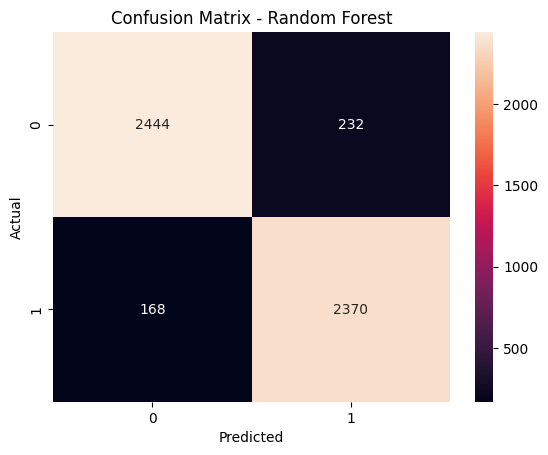

In [17]:
# =========================
# 16: Confusion Matrix
# =========================

cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# =========================
# 17: Metrics
# =========================

print("Precision:", precision_score(y_test, rf.predict(X_test)))
print("Recall:", recall_score(y_test, rf.predict(X_test)))
print("F1 Score:", f1_score(y_test, rf.predict(X_test)))


Precision: 0.9108378170637971
Recall: 0.933806146572104
F1 Score: 0.9221789883268483


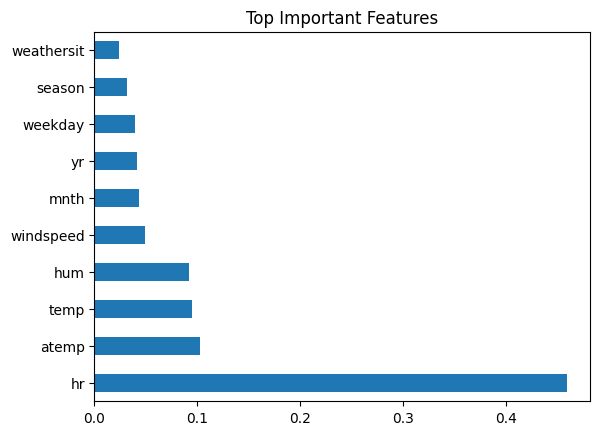

In [19]:
# =========================
# 18: Feature Importance
# =========================

importances = rf.feature_importances_
feature_names = X.columns
feature_imp = pd.Series(importances, index=feature_names)

feature_imp.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

In [20]:
# =========================
# 19: Final Tables
# =========================

df_8020 = pd.DataFrame(results_8020, columns=['Model', 'Accuracy'])
df_7030 = pd.DataFrame(results_7030, columns=['Model', 'Accuracy'])

print("\n==============================")
print("80:20 SPLIT PERFORMANCE")
print("==============================")
print(df_8020)

print("\n==============================")
print("70:30 SPLIT PERFORMANCE")
print("==============================")
print(df_7030)


80:20 SPLIT PERFORMANCE
                 Model  Accuracy
0  Logistic Regression  0.781646
1        Decision Tree  0.909379
2        Random Forest  0.926928
3                  SVM  0.881185
4                  KNN  0.844074
5          Naive Bayes  0.792290

70:30 SPLIT PERFORMANCE
                 Model  Accuracy
0  Logistic Regression  0.791715
1        Decision Tree  0.908707
2        Random Forest  0.923283
3                  SVM  0.882048
4                  KNN  0.844265
5          Naive Bayes  0.797660
